# Classification

## Binary classification with Logistic Regression

In the following example, we'll use Logistic Regression (we'll go into detail about this algorithm in the next lecture) to classify breast tumors as malignant or benign based on the physical properties of the tumor (e.g. size, shape, texture).

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [2]:

# Load the breast cancer dataset
bc_df, y = load_breast_cancer(return_X_y=True, as_frame=True)

# The original dataset maps 0=malignant, 1=benign. This feels backwards to me, so I swap 0 and 1
y = 1-y #swapping
display(bc_df.describe())
display(y.describe())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


,target
count,569.000000
mean,0.372583
std,0.483918
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [4]:
#splitting & training data
X_train, X_test, y_train, y_test = train_test_split(bc_df, y, test_size=0.2)

#standardizing
sc = StandardScaler()
Z_train = sc.fit_transform(X_train)
Z_test = sc.transform(X_test)
#fitting scalar to training data and appplying to both training and testing

In [5]:
#Making Model
logreg = LogisticRegression()
#fitting Model
logreg.fit(Z_train, y_train)

LogisticRegression()

In [6]:
logreg.__dict__

{'penalty': 'l2',
 'dual': False,
 'tol': 0.0001,
 'C': 1.0,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'class_weight': None,
 'random_state': None,
 'solver': 'lbfgs',
 'max_iter': 100,
 'multi_class': 'deprecated',
 'verbose': 0,
 'warm_start': False,
 'n_jobs': None,
 'l1_ratio': None,
 'n_features_in_': 30,
 'classes_': array([0, 1]),
 'n_iter_': array([20], dtype=int32),
 'coef_': array([[ 0.28222522,  0.342721  ,  0.26275059,  0.37596597,  0.18550051,
         -0.62640518,  0.70822887,  0.85404982, -0.2779947 , -0.19954734,
          1.33659427, -0.26539903,  0.7288825 ,  1.042043  ,  0.33316139,
         -0.59795384, -0.07107884,  0.13086916, -0.27327936, -0.68689311,
          0.98115164,  1.21295803,  0.77724241,  0.95878219,  0.78402565,
         -0.05817399,  0.73059002,  0.98144506,  0.94988643,  0.35750095]]),
 'intercept_': array([0.21165352])}

In [8]:
feature_names = list(bc_df.columns)

coefs = logreg.coef_.flatten()
# coefs # This line is commented out as it's not needed for the final output

idx = np.argsort(np.abs(coefs))
# idx # This line is commented out as it's not needed for the final output

for i in idx[::-1]:
  print(f'{feature_names[i]:<30} {coefs[i]}')

radius error                   1.3365942706078184
worst texture                  1.2129580302130574
area error                     1.0420430009283888
worst concave points           0.9814450575184605
worst radius                   0.9811516391157018
worst area                     0.9587821929232512
worst symmetry                 0.9498864292700178
mean concave points            0.8540498231821975
worst smoothness               0.7840256458144662
worst perimeter                0.7772424110929753
worst concavity                0.7305900201717448
perimeter error                0.7288825022722029
mean concavity                 0.7082288657866013
fractal dimension error        -0.6868931145178795
mean compactness               -0.6264051761841553
compactness error              -0.5979538402414777
mean area                      0.3759659740835546
worst fractal dimension        0.3575009491508878
mean texture                   0.3427209950598066
smoothness error               0.33316139067918

In [10]:
#Making predicitions
y_pred_train = logreg.predict(Z_train)
y_pred_test = logreg.predict(Z_test)

#predictions of probabilities
y_prob_train = logreg.predict_proba(Z_train)
y_prob_test = logreg.predict_proba(Z_test)


In [11]:
y_pred_test

array([0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1])

In [12]:
y_prob_test

array([[9.91951062e-01, 8.04893843e-03],
       [9.98239168e-01, 1.76083184e-03],
       [3.55619857e-01, 6.44380143e-01],
       [2.09549432e-02, 9.79045057e-01],
       [9.99746925e-01, 2.53075297e-04],
       [3.52697171e-04, 9.99647303e-01],
       [9.99978082e-01, 2.19182896e-05],
       [9.99902618e-01, 9.73817818e-05],
       [7.25258563e-01, 2.74741437e-01],
       [9.95339049e-01, 4.66095060e-03],
       [4.17048725e-03, 9.95829513e-01],
       [2.57675258e-06, 9.99997423e-01],
       [0.00000000e+00, 1.00000000e+00],
       [1.16548379e-01, 8.83451621e-01],
       [4.63607159e-01, 5.36392841e-01],
       [9.84245568e-01, 1.57544320e-02],
       [9.89113104e-01, 1.08868957e-02],
       [3.68007873e-02, 9.63199213e-01],
       [9.94978052e-01, 5.02194804e-03],
       [9.81142323e-05, 9.99901886e-01],
       [3.69304072e-04, 9.99630696e-01],
       [9.99508226e-01, 4.91774041e-04],
       [9.99224682e-01, 7.75318406e-04],
       [9.99462527e-01, 5.37473491e-04],
       [9.999824

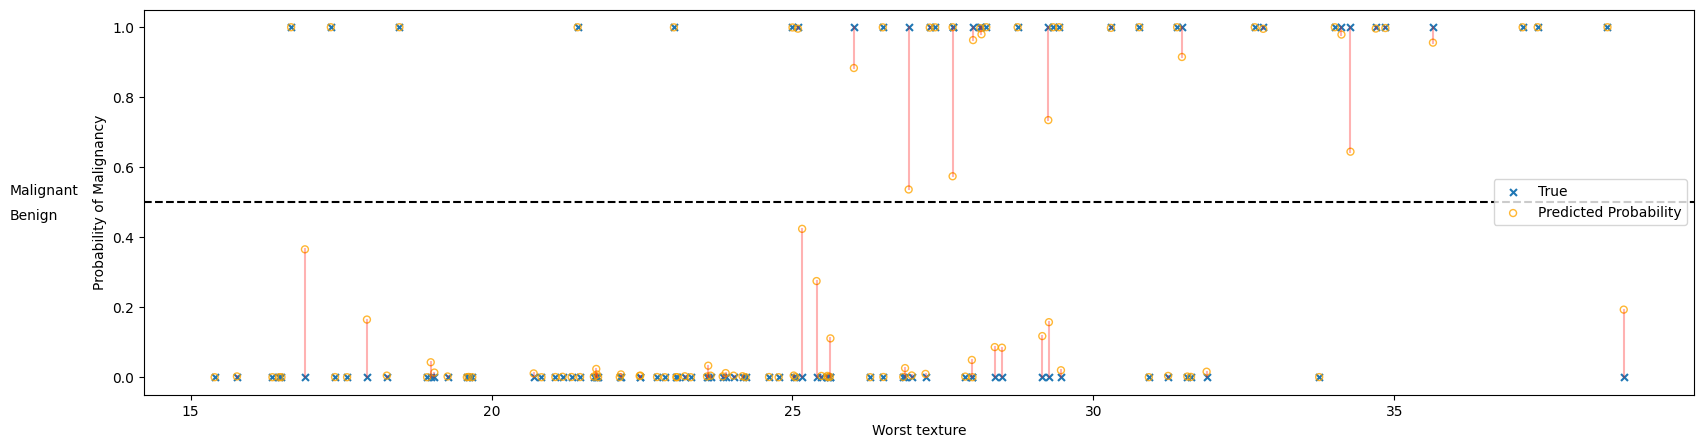

In [13]:
plt.subplots(1,1, figsize = (20, 5))
plt.scatter(X_test['worst texture'], y_test, label = 'True',
            s = 25, marker = 'x')

plt.scatter(X_test['worst texture'], y_prob_test[:,1], label = 'Predicted Probability',
            s = 25,
            alpha = 0.8, marker = 'o', ec = 'orange', facecolor = 'none')

plt.plot(np.matlib.repmat(X_test['worst texture'].to_numpy().reshape(1,-1), 2,1), np.column_stack((y_test, y_prob_test[:,1])).T, 'r-',
            alpha = 0.3, marker = 'none')

plt.axhline(0.5, c = 'k', ls = '--')
plt.text(12, 0.52, 'Malignant')
plt.text(12, 0.45, 'Benign')

plt.legend()
plt.xlabel('Worst texture')
plt.ylabel('Probability of Malignancy')
plt.show()

## Model Assessment

### Confusion Matrix

The *Confusion Matrix* is a graphical representation of the predictions a classifier has made on the data set. The confusion matrix is an nxn grid where n is the number of categories; for binary classification, the confusion matrix is always 2x2.

Let's look at the confusion matrix for the breast tumor classification above.

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, precision_recall_curve, PrecisionRecallDisplay


In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        # normalize = 'true',
                                        # display_labels = ['Benign', 'Malignant'],
                                        display_labels = ['Neg', 'Pos'],
                                        cmap = 'GnBu'
                                        )
plt.show()

In [ ]:

cr = classification_report(y_test, y_pred_test, target_names = ['Benign', 'Malignant'])
print(cr)

In [ ]:
PrecisionRecallDisplay.from_estimator(model, X_train, y_train)
plt.show()